importing important libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

reading data file 

In [59]:
df=pd.read_csv('insurance.csv')

In [60]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

step 1: view data

In [61]:
df.shape

(1338, 7)

In [62]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [64]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [65]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

step 2 : Data spreadness (normal distribution, skewness etc)

In [66]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [67]:
#select only numeric datatype 
numeric_columns = df.select_dtypes(include = 'number').columns
numeric_columns

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

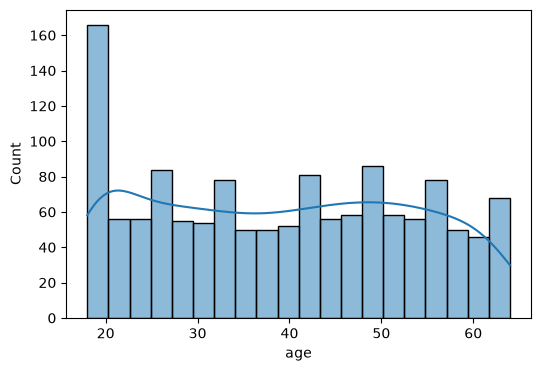

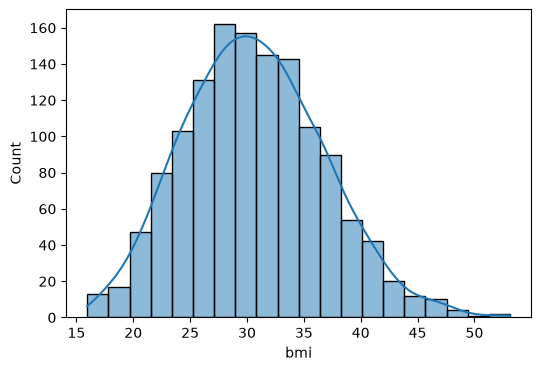

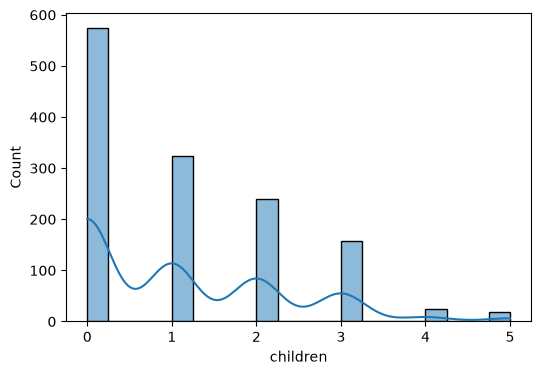

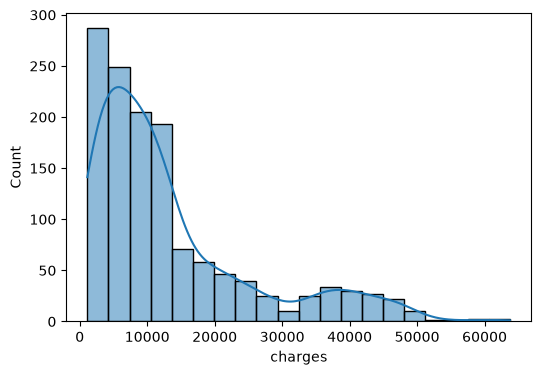

In [68]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col] , kde=True , bins =20 )

To analyze the categorical data 

In [69]:
categorical_data = df.select_dtypes( include='object').columns
categorical_data

Index(['sex', 'smoker', 'region'], dtype='str')

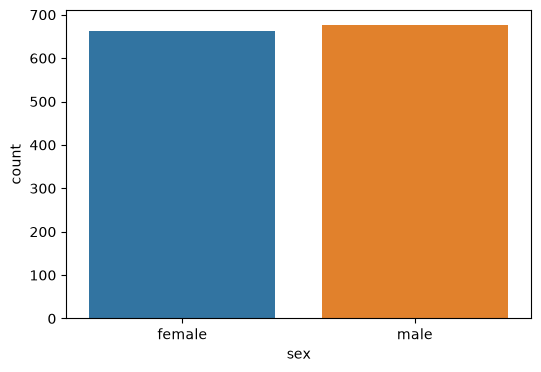

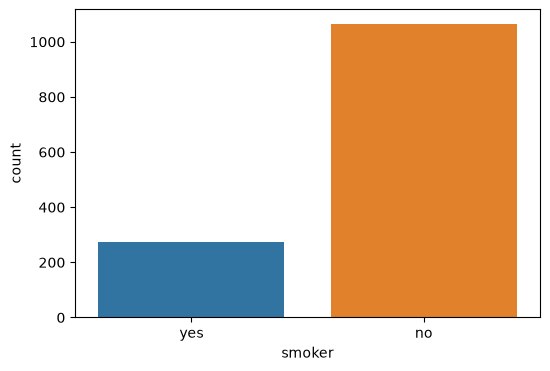

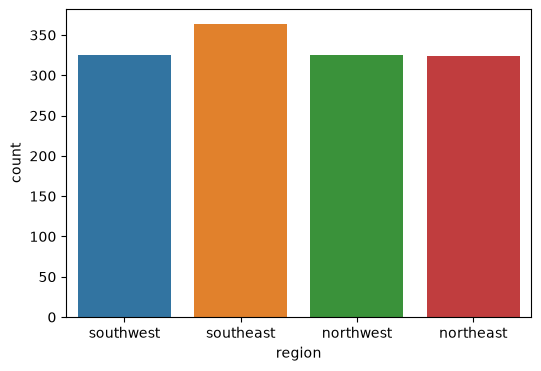

In [70]:
for i in categorical_data:
    plt.figure(figsize=(6,4))
    sns.countplot(x= i, hue=i , data=df )

Creating box plot : used for numerical data 

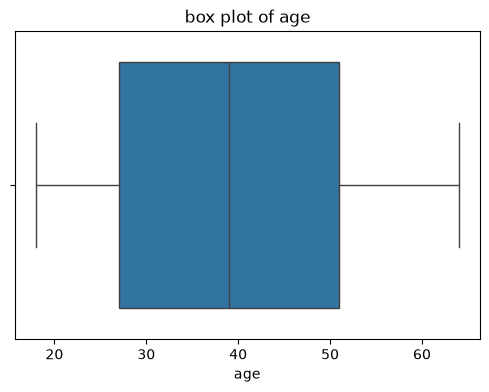

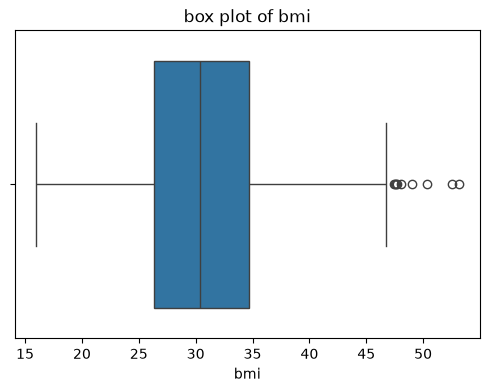

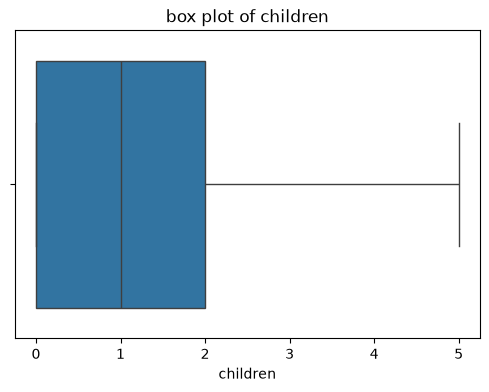

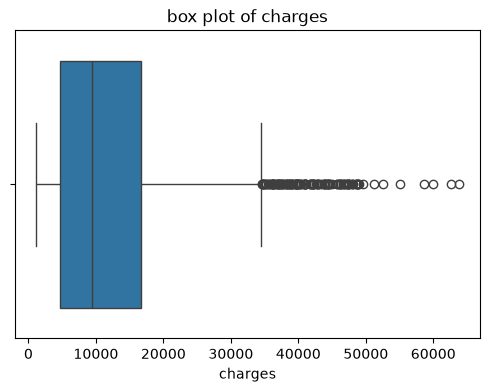

In [71]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])
    plt.title(f'box plot of {col}')


<Axes: >

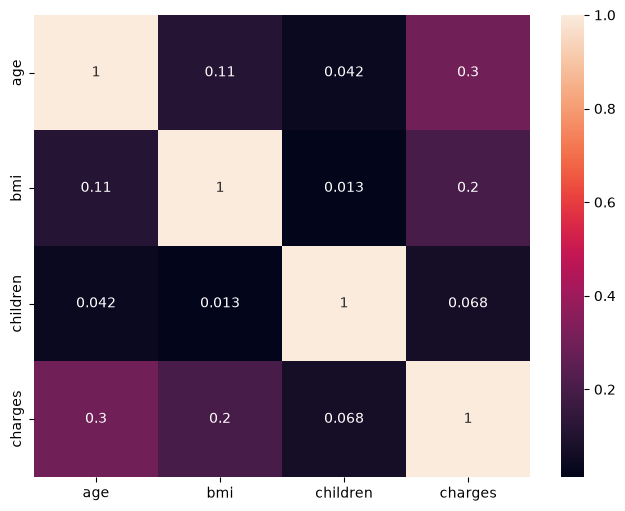

In [72]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

DATA CLEANING AND PREPROCESSING 

In [73]:
df_cleaned=df.copy()

In [74]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [75]:
#remove duplicates rows 
df_cleaned.drop_duplicates(inplace = True)

In [76]:
df.shape

(1338, 7)

In [77]:
df_cleaned.shape

(1337, 7)

In [78]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [79]:
df_cleaned['sex'].value_counts() #to know if gender is male and female only , if there is any 
#different type of gender like MALE it will a separate column and then we need to handle inconsistent categorical 

sex
male      675
female    662
Name: count, dtype: int64

In [80]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [81]:
#we prefer data in numeric and in 1 0 more as it is easy 
#therefore we will convert smoker and sex into 0 1 data 

In [85]:
print(df['sex'].unique())

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str


In [86]:
df_cleaned=df.copy()

In [87]:
print(df_cleaned['sex'].unique())

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str


In [88]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [89]:
df_cleaned.rename(
    columns= {
        "sex" :"is_female" ,
        "smoker" :"do_smoke"
    } , inplace = True
)

In [90]:
df_cleaned.head()

,age,is_female,bmi,children,do_smoke,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [93]:
df_cleaned['is_female'] = df_cleaned['is_female'].map({"male" : 0,"female" : 1})
df_cleaned['do_smoke'] = df_cleaned['do_smoke'].map({"no" : 0,"yes" : 1})

In [94]:
df_cleaned.head()

,age,is_female,bmi,children,do_smoke,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [95]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [96]:
#get_dummies() converts categorical values into numerical columns.
#one-hot encoding.

#drop_first=True → remove one category to avoid redundant dummy variables.

#get_dummies() returns a new DataFrame. It doesn't modify df_cleaned unless you assign it.
df_cleaned = pd.get_dummies(df_cleaned , columns=['region'] , drop_first=True)

In [98]:
df_cleaned.head()

,age,is_female,bmi,children,do_smoke,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [100]:
#if all three region are false then ofcourse it will be northeast .
#no need to form redundant data 

In [101]:
#convert data into int 
df_cleaned=df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,do_smoke,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


Feature Engineering and Extraction 

<Axes: xlabel='bmi', ylabel='Count'>

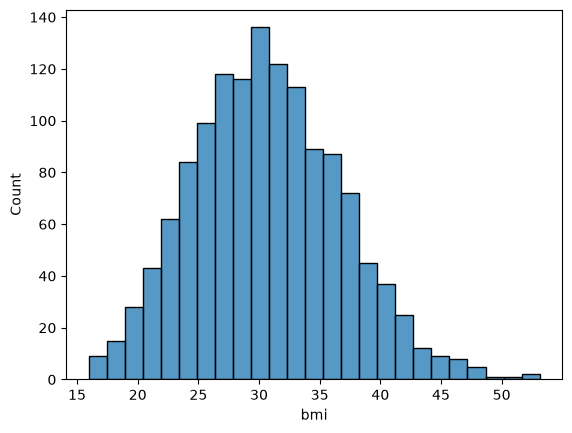

In [102]:
sns.histplot(df['bmi'])

In [103]:
#now i want to get the column saying : obese , owerweight , underweight , normal 

In [104]:
#pd.cut() is used to divide numerical values into intervals (bins) and 
#assign each value a category.

df_cleaned['you_are'] = pd.cut(
    df_cleaned['bmi'] , 
    bins=[0 , 18.5 , 25 , 30 , float('inf')],
    labels=['underweight' , 'Normal' , 'owerweight' , 'Obese']
)
df_cleaned

,age,is_female,bmi,children,do_smoke,charges,region_northwest,region_southeast,region_southwest,you_are
0,19,1,27,0,1,16884,0,0,1,owerweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,owerweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,owerweight
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Normal


In [106]:
#standardisation 
from sklearn.preprocessing import StandardScaler
cols=['age' , 'bmi' , 'children']
scaler =StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [107]:
df_cleaned.head()

,age,is_female,bmi,children,do_smoke,charges,region_northwest,region_southeast,region_southwest,you_are
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,owerweight
1,-1.509965,0,0.462657,-0.078767,0,1725,0,1,0,Obese
2,-0.797954,0,0.462657,1.580926,0,4449,0,1,0,Obese
3,-0.441948,0,-1.335438,-0.908614,0,21984,1,0,0,Normal
4,-0.513149,0,-0.354659,-0.908614,0,3866,1,0,0,owerweight
